In [1]:

# ============================================================
# PARTIE I — MLP sur données tabulaires
# Dataset : Breast Cancer Wisconsin
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)

# Vérifier si GPU disponible, sinon utiliser CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")
print(f"Version PyTorch : {torch.__version__}")


Device utilisé : cpu
Version PyTorch : 2.12.0+cpu


In [2]:

# ── 1. Chargement du dataset ──────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target
print(f"Taille du dataset : {X.shape}")   # (569, 30)
print(f"Classes : {data.target_names}")    # malignant / benign

# ── 2. Séparation train / validation / test ───────────────
# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")

# ── 3. Normalisation (StandardScaler) ────────────────────
# IMPORTANT : on fit uniquement sur le train, jamais sur val/test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# ── 4. Conversion en tenseurs PyTorch ────────────────────
def to_tensors(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long))

X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t,   y_val_t   = to_tensors(X_val,   y_val)
X_test_t,  y_test_t  = to_tensors(X_test,  y_test)

# ── 5. DataLoaders (mini-batches) ────────────────────────
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=32)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                          batch_size=32)

print("Données prêtes ✓")


Taille du dataset : (569, 30)
Classes : ['malignant' 'benign']
Train : 398 | Val : 85 | Test : 86
Données prêtes ✓


In [3]:

# ══════════════════════════════════════════════════════════
# VERSION A : nn.Sequential  (rapide à écrire)
# ══════════════════════════════════════════════════════════
mlp_sequential = nn.Sequential(
    nn.Linear(30, 64),   # couche d'entrée : 30 features
    nn.ReLU(),
    nn.Dropout(0.3),     # régularisation : désactive 30% des neurones
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 2)     # couche de sortie : 2 classes
)

# ══════════════════════════════════════════════════════════
# VERSION B : Classe personnalisée (plus flexible, recommandée)
# ══════════════════════════════════════════════════════════
class MLP(nn.Module):
    """
    Perceptron multicouche pour classification binaire.
    Architecture : 30 → 64 → 32 → 2
    """
    def __init__(self, input_dim=30, hidden1=64, hidden2=32, n_classes=2):
        super().__init__()
        self.fc1     = nn.Linear(input_dim, hidden1)
        self.fc2     = nn.Linear(hidden1, hidden2)
        self.fc3     = nn.Linear(hidden2, n_classes)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Propagation avant : x passe dans chaque couche
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)   # pas d'activation ici (CrossEntropyLoss l'inclut)
        return x

# Instancier le modèle et l'envoyer sur le bon device
model = MLP().to(device)
print(model)
print(f"\nNombre de paramètres : {sum(p.numel() for p in model.parameters()):,}")


MLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

Nombre de paramètres : 4,130


In [4]:

# ── Inspection des paramètres ─────────────────────────────
print("=== named_parameters() ===")
for name, param in model.named_parameters():
    print(f"  {name:20s} | shape: {str(param.shape):20s} | requires_grad: {param.requires_grad}")

print("\n=== Clés du state_dict() ===")
for key in model.state_dict():
    print(f"  {key}")

# ── 3 stratégies d'initialisation ────────────────────────
def init_gaussian(m):
    """Initialisation gaussienne (normale) : N(0, 0.01)"""
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        nn.init.zeros_(m.bias)

def init_constant(m):
    """Initialisation constante : tous les poids = 0.1"""
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0.1)
        nn.init.zeros_(m.bias)

def init_xavier(m):
    """Initialisation Xavier (Glorot) : recommandée pour ReLU/Tanh"""
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

# On applique Xavier (meilleure pratique)
model.apply(init_xavier)
print("\nInitialisation Xavier appliquée ✓")
print(f"Poids fc1 — moyenne : {model.fc1.weight.data.mean():.4f}, std : {model.fc1.weight.data.std():.4f}")


=== named_parameters() ===
  fc1.weight           | shape: torch.Size([64, 30]) | requires_grad: True
  fc1.bias             | shape: torch.Size([64])     | requires_grad: True
  fc2.weight           | shape: torch.Size([32, 64]) | requires_grad: True
  fc2.bias             | shape: torch.Size([32])     | requires_grad: True
  fc3.weight           | shape: torch.Size([2, 32])  | requires_grad: True
  fc3.bias             | shape: torch.Size([2])      | requires_grad: True

=== Clés du state_dict() ===
  fc1.weight
  fc1.bias
  fc2.weight
  fc2.bias
  fc3.weight
  fc3.bias

Initialisation Xavier appliquée ✓
Poids fc1 — moyenne : 0.0043, std : 0.1457


In [5]:

# ── Définir la loss et l'optimiseur ──────────────────────
criterion = nn.CrossEntropyLoss()          # perte pour classification
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ── Boucle d'entraînement ────────────────────────────────
N_EPOCHS = 80
history = {"train_loss": [], "val_loss": [],
           "train_acc": [],  "val_acc": []}
best_val_loss = float("inf")

for epoch in range(N_EPOCHS):

    # ── Phase TRAIN ──
    model.train()                          # active dropout
    train_loss, train_correct = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()              # remet les gradients à 0
        preds = model(xb)                  # propagation avant
        loss  = criterion(preds, yb)       # calcul de la perte
        loss.backward()                    # rétropropagation
        optimizer.step()                   # mise à jour des poids
        train_loss    += loss.item() * xb.size(0)
        train_correct += (preds.argmax(1) == yb).sum().item()

    # ── Phase VALIDATION ──
    model.eval()                           # désactive dropout
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():                  # pas de gradients en val
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds     = model(xb)
            val_loss += criterion(preds, yb).item() * xb.size(0)
            val_correct += (preds.argmax(1) == yb).sum().item()

    # ── Calcul des métriques ──
    n_train, n_val = len(X_train_t), len(X_val_t)
    tl = train_loss / n_train;  vl = val_loss / n_val
    ta = train_correct / n_train; va = val_correct / n_val
    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta);  history["val_acc"].append(va)

    # ── Sauvegarde du meilleur modèle ──
    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(model.state_dict(), "best_mlp.pth")

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | "
              f"Train loss: {tl:.4f}  acc: {ta:.3f} | "
              f"Val   loss: {vl:.4f}  acc: {va:.3f}")

print("\nEntraînement terminé ✓ — meilleur modèle sauvegardé dans best_mlp.pth")


Epoch  10/80 | Train loss: 0.0966  acc: 0.970 | Val   loss: 0.0572  acc: 0.988
Epoch  20/80 | Train loss: 0.0655  acc: 0.985 | Val   loss: 0.0451  acc: 0.976
Epoch  30/80 | Train loss: 0.0523  acc: 0.987 | Val   loss: 0.0557  acc: 0.976
Epoch  40/80 | Train loss: 0.0402  acc: 0.990 | Val   loss: 0.0527  acc: 0.976
Epoch  50/80 | Train loss: 0.0233  acc: 0.990 | Val   loss: 0.0592  acc: 0.976
Epoch  60/80 | Train loss: 0.0277  acc: 0.990 | Val   loss: 0.0716  acc: 0.976
Epoch  70/80 | Train loss: 0.0139  acc: 0.992 | Val   loss: 0.0788  acc: 0.976
Epoch  80/80 | Train loss: 0.0265  acc: 0.990 | Val   loss: 0.0666  acc: 0.976

Entraînement terminé ✓ — meilleur modèle sauvegardé dans best_mlp.pth


=== Résultats sur le Test Set ===
  Accuracy  : 0.9535
  Precision : 0.9630
  Recall    : 0.9630
  F1-score  : 0.9630

              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        32
      benign       0.96      0.96      0.96        54

    accuracy                           0.95        86
   macro avg       0.95      0.95      0.95        86
weighted avg       0.95      0.95      0.95        86



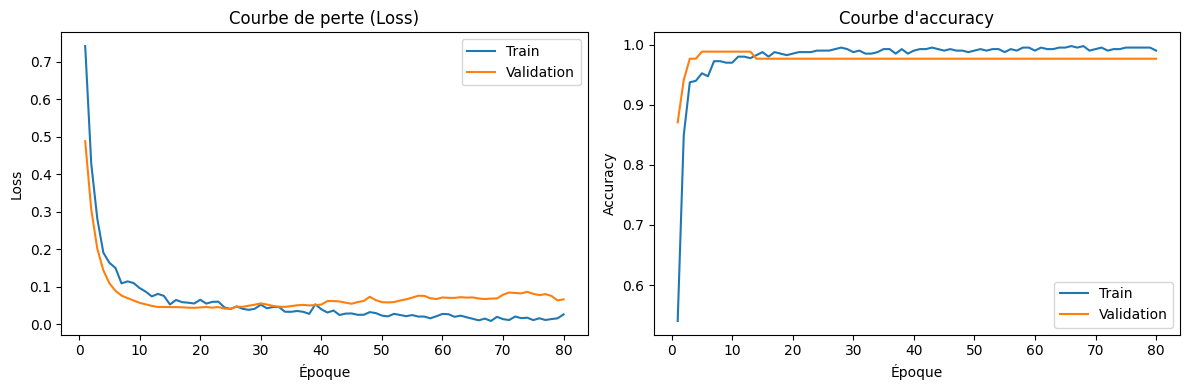

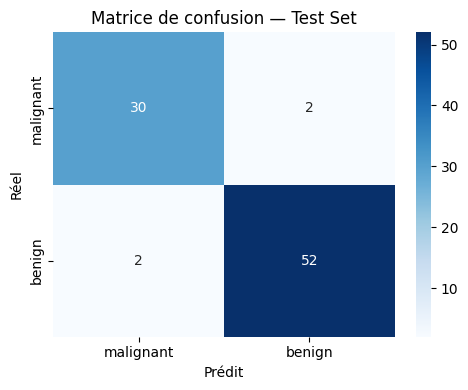

In [6]:

# ── Recharger le meilleur modèle ─────────────────────────
model.load_state_dict(torch.load("best_mlp.pth", map_location=device))
model.eval()

# ── Prédictions sur le test set ──────────────────────────
with torch.no_grad():
    logits = model(X_test_t.to(device))
    y_pred = logits.argmax(dim=1).cpu().numpy()
y_true = y_test_t.numpy()

# ── Métriques ────────────────────────────────────────────
print("=== Résultats sur le Test Set ===")
print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
print(f"  F1-score  : {f1_score(y_true, y_pred):.4f}")
print("\n" + classification_report(y_true, y_pred,
      target_names=data.target_names))

# ── Figure 1 : Courbes Loss et Accuracy ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, N_EPOCHS+1)

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Validation")
axes[0].set_title("Courbe de perte (Loss)"); axes[0].legend()
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Loss")

axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Validation")
axes[1].set_title("Courbe d'accuracy"); axes[1].legend()
axes[1].set_xlabel("Époque"); axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.savefig("courbes_mlp.png", dpi=150)
plt.show()

# ── Figure 2 : Matrice de confusion ──────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title("Matrice de confusion — Test Set")
plt.ylabel("Réel"); plt.xlabel("Prédit")
plt.tight_layout()
plt.savefig("confusion_mlp.png", dpi=150)
plt.show()
